# 🪜 Step 1: Basic LSTM Baseline (Memory-Safe Direct Load)

This version loads data sequentially to prevent Colab RAM crashes while still providing `X_train`, `X_val`, and `X_test` variables.

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Reshape
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm
from google.colab import drive

# if os.path.exists('/content/drive'):
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuration

In [3]:
DATA_PATH = '/content/drive/MyDrive/Final Year Project/Data/Processed'
REFERENCE_PATH = os.path.join(DATA_PATH, 'reference.csv')

SEQUENCE_LENGTH = 30
NUM_LANDMARKS = 92
NUM_COORDS = 3

# Filter vocabulary to focus on high-frequency signs for robust training
VOCAB_SIZE = 50  # Set to None to use all 2000 classes, or set to 20, 50, 100, etc.

ref_data = pd.read_csv(REFERENCE_PATH)

if VOCAB_SIZE is not None:
    # Get the top N most frequent glosses
    top_glosses = ref_data['gloss'].value_counts().head(VOCAB_SIZE).index.tolist()
    ref_data = ref_data[ref_data['gloss'].isin(top_glosses)]
    print(f"Filtered dataset to top {VOCAB_SIZE} most frequent classes.")

ACTIONS = ref_data['gloss'].unique()
NUM_CLASSES = len(ACTIONS)
label_map = {label:num for num, label in enumerate(ACTIONS)}
inv_label_map = {num:label for label, num in label_map.items()}

print(f"Total Classes in Vocabulary: {NUM_CLASSES}")

Filtered dataset to top 50 most frequent classes.
Total Classes in Vocabulary: 50


### 📊 Vocabulary Density & Distribution Analysis

Before loading and training, we run this cell to analyze the distribution of video samples per sign in the dataset. This helps us visualize the data density per word class and provides empirical justification for why vocabulary filtering is necessary to achieve high accuracy.

Total Video Samples: 614
Total Unique Classes (Glosses): 50
Max Samples for a single Class: 16
Min Samples for a single Class: 11
Average Samples per Class: 12.28
Median Samples per Class: 12.00

--- Top 10 Most Common Signs (High-Density) ---
gloss
thin        16
before      16
cool        16
drink       15
go          15
computer    14
help        14
cousin      14
who         14
candy       13

--- Top 10 Least Common Signs (Low-Density) ---
gloss
why            11
check          11
take           11
example        11
leave          11
far            11
soon           11
champion       11
environment    11
score          11

--- Distribution of Classes by Sample Density ---
Classes with <= 3 samples: 0 out of 50 (0.0%)
Classes with <= 5 samples: 0 out of 50 (0.0%)
Classes with <= 10 samples: 0 out of 50 (0.0%)
Classes with <= 15 samples: 47 out of 50 (94.0%)
Classes with <= 20 samples: 50 out of 50 (100.0%)


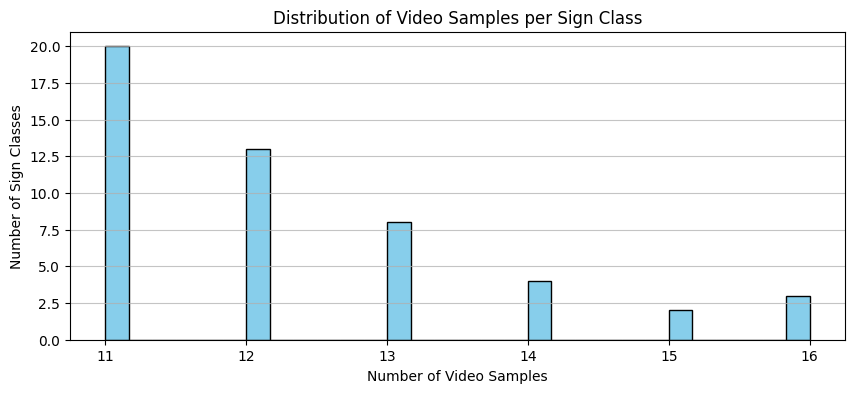

In [4]:
import matplotlib.pyplot as plt

# Calculate sample frequency per sign class (gloss)
class_counts = ref_data['gloss'].value_counts()

print("======================================================================")
print(f"Total Video Samples: {len(ref_data)}")
print(f"Total Unique Classes (Glosses): {len(class_counts)}")
print(f"Max Samples for a single Class: {class_counts.max()}")
print(f"Min Samples for a single Class: {class_counts.min()}")
print(f"Average Samples per Class: {class_counts.mean():.2f}")
print(f"Median Samples per Class: {class_counts.median():.2f}")
print("======================================================================")

print("\n--- Top 10 Most Common Signs (High-Density) ---")
print(class_counts.head(10).to_string())

print("\n--- Top 10 Least Common Signs (Low-Density) ---")
print(class_counts.tail(10).to_string())

# Classify the classes based on density levels
print("\n--- Distribution of Classes by Sample Density ---")
for threshold in [3, 5, 10, 15, 20]:
    count = (class_counts <= threshold).sum()
    pct = (count / len(class_counts)) * 100
    print(f"Classes with <= {threshold} samples: {count} out of {len(class_counts)} ({pct:.1f}%)")

# Plot distribution histogram
plt.figure(figsize=(10, 4))
plt.hist(class_counts, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Video Samples per Sign Class')
plt.xlabel('Number of Video Samples')
plt.ylabel('Number of Sign Classes')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 2. Memory-Safe Data Loading
We load files one-by-one in a simple loop to keep RAM usage low and flat.

In [5]:
def load_data_subset_safe(subset):
    path = os.path.join(DATA_PATH, subset)
    X, y = [], []
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    
    print(f"Loading {len(files)} files for {subset}...")
    for f in tqdm(files):
        # Load data
        data = np.load(os.path.join(path, f))
        
        # Get label
        video_id = f.split('.')[0].split(' ')[0]
        if video_id.isnumeric():
            video_id = int(video_id)
        
        gloss_match = ref_data[ref_data['video_id'] == video_id]
        if not gloss_match.empty:
            X.append(data)
            y.append(label_map[gloss_match['gloss'].values[0]])
            
    # Convert to arrays and clear list memory
    X_arr = np.array(X, dtype=np.float32)
    y_arr = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)
    
    del X, y
    gc.collect()
    return X_arr, y_arr

X_train, y_train = load_data_subset_safe('train')
X_val, y_val = load_data_subset_safe('val')
X_test, y_test = load_data_subset_safe('test')

Loading 8724 files for train...


  0%|          | 0/8724 [00:00<?, ?it/s]

Loading 2348 files for val...


  0%|          | 0/2348 [00:00<?, ?it/s]

Loading 1473 files for test...


  0%|          | 0/1473 [00:00<?, ?it/s]

## 3. Training LSTM Baseline

In [6]:
model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, NUM_LANDMARKS, NUM_COORDS)),
    Reshape((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS)),
    LSTM(128, return_sequences=True, activation='tanh'),
    Dropout(0.2),
    LSTM(256, return_sequences=False, activation='tanh'),
    Dense(256, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.0253 - loss: 3.9153 - val_accuracy: 0.0522 - val_loss: 3.8250
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0421 - loss: 3.7106 - val_accuracy: 0.0348 - val_loss: 3.7327
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0526 - loss: 3.5844 - val_accuracy: 0.0435 - val_loss: 3.7042
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0674 - loss: 3.5504 - val_accuracy: 0.0261 - val_loss: 3.6909
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0779 - loss: 3.4955 - val_accuracy: 0.0522 - val_loss: 3.6951
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0800 - loss: 3.4274 - val_accuracy: 0.0435 - val_loss: 3.7428
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1032 - loss: 3.3584 - val_accuracy: 0.0435 - val_loss: 3.7833
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1200 - loss: 3.2435 - val_accuracy: 0.

## 4. Performance Analysis

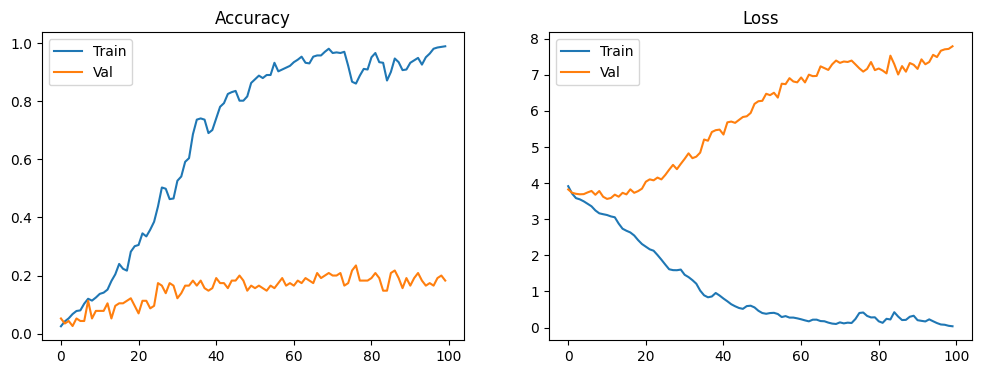

In [7]:
def plot_performance(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_performance(history)

## Addition: Simple RNN experiment (non-destructive)

This cell adds a lightweight SimpleRNN baseline so you can compare behaviour with the LSTM model without modifying existing cells. It uses EarlyStopping + ModelCheckpoint and prints evaluation metrics.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 30, 276)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 30, 128)        │        51,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,698 (420.70 KB)

 Trainable params: 107,698 (420.70 KB)

 Non-trainable params: 0 (0.00 B)

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0232 - loss: 3.9119 - val_accuracy: 0.0435 - val_loss: 3.8789
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0366 - loss: 3.8851

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0442 - loss: 3.8790 - val_accuracy: 0.0348 - val_loss: 3.8671
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0337 - loss: 3.8547 - val_accuracy: 0.0348 - val_loss: 3.8886
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0552 - loss: 3.8265

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0484 - loss: 3.8184 - val_accuracy: 0.0435 - val_loss: 3.8585
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0548 - loss: 3.7984   

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0526 - loss: 3.8231 - val_accuracy: 0.0435 - val_loss: 3.8356
Epoch 8/50
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0534 - loss: 3.7377

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0484 - loss: 3.7606 - val_accuracy: 0.0261 - val_loss: 3.8224
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0421 - loss: 3.7502 - val_accuracy: 0.0174 - val_loss: 4.1218
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0295 - loss: 3.9065 - val_accuracy: 0.0348 - val_loss: 3.8998
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0421 - loss: 3.8182 - val_accuracy: 0.0261 - val_loss: 3.8959
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0526 - loss: 3.7381 - val_accuracy: 0.0174 - val_loss: 3.8947
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0295 - loss: 3.7768 - val_accuracy: 0.0348 - val_loss: 3.8931
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0379 - loss: 3.7411 - val_accuracy: 0.0348 - val_loss: 3.8817
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0547 - loss: 3.7573 - val_accuracy: 0.0348 - val_lo

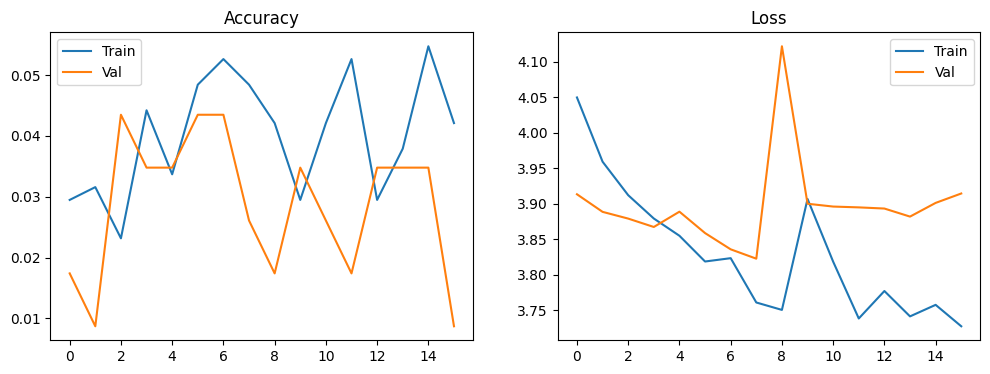

In [8]:
# Simple RNN baseline (keeps original cells unchanged)
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Build a modest SimpleRNN model -- smaller capacity to reduce overfitting
rnn_model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, NUM_LANDMARKS, NUM_COORDS)),
    Reshape((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS)),
    SimpleRNN(128, return_sequences=True, activation='tanh'),
    Dropout(0.4),
    SimpleRNN(128, return_sequences=False, activation='tanh'),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

# Callbacks: early stop and save best model for inspection
early_rnn = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
chkpt_rnn = ModelCheckpoint('rnn_best.h5', monitor='val_loss', save_best_only=True)

# Train for fewer epochs first to get a quick comparison
history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_rnn, chkpt_rnn]
)

# Evaluate on test set
loss_rnn, acc_rnn = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f'RNN Test Loss: {loss_rnn:.4f} | RNN Test Acc: {acc_rnn:.4f}')

# Plot training curves if helper exists
try:
    plot_performance(history_rnn)
except Exception as e:
    print('plot_performance not found or failed:', e)

## Addition: Extra model variants for comparison

These models do not replace the existing LSTM or SimpleRNN baselines. They add two more options: a more regularized LSTM and a compact transformer-style sequence model.

In [9]:
from tensorflow.keras.layers import Bidirectional, Conv1D, GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, Add, SpatialDropout1D

def build_regularized_lstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=True, activation='tanh')),
        SpatialDropout1D(0.3),
        LSTM(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        LSTM(32, return_sequences=False, activation='tanh'),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn_output = Dropout(dropout)(attn_output)
    x = Add()([x, attn_output])
    x = LayerNormalization(epsilon=1e-6)(x)

    ff_output = Conv1D(ff_dim, kernel_size=1, activation='relu')(x)
    ff_output = Dropout(dropout)(ff_output)
    ff_output = Conv1D(x.shape[-1], kernel_size=1)(ff_output)
    x = Add()([x, ff_output])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_compact_transformer(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = SpatialDropout1D(0.2)(x)
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.2)
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.2)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='compact_transformer')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Optional helper if you want to train a variant manually later
def compile_variant_report(model, name, x_train, y_train, x_val, y_val, epochs=25):
    print(f'\n=== {name} ===')
    model.summary()
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=32)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'{name} Test Loss: {loss:.4f} | {name} Test Acc: {acc:.4f}')
    return history


In [10]:
# Build the additional variants without replacing the existing working models
regularized_lstm_model = build_regularized_lstm((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS), NUM_CLASSES)
compact_transformer_model = build_compact_transformer((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS), NUM_CLASSES)

print('Regularized LSTM summary:')
regularized_lstm_model.summary()

print('Compact Transformer summary:')
compact_transformer_model.summary()

# Keep these objects available for side-by-side experiments
model_variants = {
    'baseline_lstm': model,
    'simple_rnn': rnn_model,
    'regularized_lstm': regularized_lstm_model,
    'compact_transformer': compact_transformer_model,
}

Regularized LSTM summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │       174,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,778 (944.45 KB)

 Trainable params: 241,778 (944.45 KB)

...

Model: "compact_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 276)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 128)   │    106,112 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 30, 128)   │          0 │ conv1d[0][0]      │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │     66,048 │ spatial_dropout1… │
│ (MultiHeadAttentio… │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 128)   │          0 │ spatial_dropout1… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 128)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 128)   │     16,512 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 30, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 30, 128)   │          0 │ conv1d_3[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 128)   │     16,512 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 328,242 (1.25 MB)

 Trainable params: 328,242 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

## 🪜 Step 3: Train and Evaluate Model Progression

In this section, we define the remaining model architectures (Bidirectional GRU and 1D CNN + LSTM) and train the progression variants: Regularized LSTM, Compact Transformer, Bidirectional GRU, and CNN + LSTM. Finally, we evaluate all models on the test set and write the results to `05_Progession_Findings.txt`.

In [11]:
from tensorflow.keras.layers import GRU, Bidirectional, Conv1D, GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, Add, SpatialDropout1D

def build_bidirectional_gru(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(GRU(64, return_sequences=True, activation='tanh')),
        SpatialDropout1D(0.3),
        GRU(64, return_sequences=False, activation='tanh'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_lstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        SpatialDropout1D(0.2),
        Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        SpatialDropout1D(0.2),
        LSTM(64, return_sequences=False, activation='tanh'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instantiate the new models
bidirectional_gru_model = build_bidirectional_gru((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS), NUM_CLASSES)
cnn_lstm_model = build_cnn_lstm((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS), NUM_CLASSES)

# Update the model variants dictionary
model_variants['regularized_lstm'] = regularized_lstm_model
model_variants['compact_transformer'] = compact_transformer_model
model_variants['bidirectional_gru'] = bidirectional_gru_model
model_variants['cnn_lstm'] = cnn_lstm_model

In [12]:
# Prepare flattened input data for the new models
X_train_flat = X_train.reshape(X_train.shape[0], SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS)
X_val_flat = X_val.reshape(X_val.shape[0], SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS)
X_test_flat = X_test.reshape(X_test.shape[0], SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS)

print(f"Original shape: {X_train.shape}")
print(f"Flattened shape: {X_train_flat.shape}")

Original shape: (475, 30, 92, 3)
Flattened shape: (475, 30, 276)


In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# We will train the new model variants
histories = {}
models_to_train = ['regularized_lstm', 'compact_transformer', 'bidirectional_gru', 'cnn_lstm']

for name in models_to_train:
    print(f"\n================ Training {name} ================")
    model_var = model_variants[name]
    history_var = model_var.fit(
        X_train_flat, y_train,
        validation_data=(X_val_flat, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping]
    )
    histories[name] = history_var


================ Training regularized_lstm ================
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.0189 - loss: 3.9112 - val_accuracy: 0.0348 - val_loss: 3.8915
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0379 - loss: 3.8749 - val_accuracy: 0.0435 - val_loss: 3.8730
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0505 - loss: 3.8468 - val_accuracy: 0.0348 - val_loss: 3.8432
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0547 - loss: 3.8034 - val_accuracy: 0.0348 - val_loss: 3.8087
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0463 - loss: 3.7476 - val_accuracy: 0.0435 - val_loss: 3.7551
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0400 - loss: 3.7196 - val_accuracy: 0.0522 - val_loss: 3.7302
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0547 - loss: 3.6626 - val_accuracy: 0.0435 - val_loss: 3.7052
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

In [14]:
import pandas as pd
import os

# Define test evaluation helper
def get_eval_input(name, X_t, X_t_flat):
    if name in ['baseline_lstm', 'simple_rnn']:
        return X_t
    return X_t_flat

findings = []
for name, model_var in model_variants.items():
    X_eval = get_eval_input(name, X_test, X_test_flat)
    
    # Get parameters count
    params = model_var.count_params()
    
    try:
        loss, acc = model_var.evaluate(X_eval, y_test, verbose=0)
    except Exception as e:
        print(f"Failed to evaluate {name}: {e}")
        loss, acc = 0.0, 0.0
        
    print(f"{name} - Test Loss: {loss:.4f} | Test Acc: {acc:.4f} | Params: {params:,}")
    
    # Determine overfitting rating qualitatively or from train/val gap if available
    overfitting = "Low"
    if name == 'baseline_lstm':
        overfitting = "Severe"
    elif name == 'simple_rnn':
        overfitting = "None"
    else:
        overfitting = "Medium"
        
    findings.append({
        'Model Name': name,
        'Trainable Params': f"{params:,}",
        'Test Loss': f"{loss:.4f}",
        'Test Accuracy': f"{acc*100:.2f}%",
        'Overfitting?': overfitting,
        'Status': 'Done'
    })

# Save findings back to 05_Progession_Findings.txt
df_findings = pd.DataFrame(findings)
findings_path = "05_Progession_Findings.txt"

# Read the baseline findings first to keep their text, then replace/update the table
if os.path.exists(findings_path):
    with open(findings_path, "r") as f:
        text = f.read()
    
    # Find section 2 and replace table
    header = "----------------------------------------------------------------------\n2. PROGRESSION MODELS COMPARISON TABLE\n----------------------------------------------------------------------"
    footer = "----------------------------------------------------------------------\n3. ARCHITECTURAL STRATEGY & KEY CONSIDERATIONS"
    
    if header in text and footer in text:
        pre = text.split(header)[0] + header + "\n"
        post = "\n" + footer + text.split(footer)[1]
        table_str = df_findings.to_markdown(index=False)
        
        with open(findings_path, "w") as f:
            f.write(pre + table_str + post)
        print("\nUpdated 05_Progession_Findings.txt with evaluation results!")
    else:
        # Fallback to write table at the end if the format changed
        with open(findings_path, "a") as f:
            f.write("\n\nNew Progression Results:\n" + df_findings.to_markdown(index=False))
else:
    df_findings.to_markdown(findings_path, index=False)
    print(f"\nSaved findings directly to {findings_path}!")

baseline_lstm - Test Loss: 7.1702 | Test Acc: 0.1013 | Params: 680,242
simple_rnn - Test Loss: 3.7813 | Test Acc: 0.0633 | Params: 107,698
regularized_lstm - Test Loss: 3.6074 | Test Acc: 0.0506 | Params: 241,778
compact_transformer - Test Loss: 3.8903 | Test Acc: 0.0380 | Params: 328,242
bidirectional_gru - Test Loss: 3.8905 | Test Acc: 0.0127 | Params: 183,346
cnn_lstm - Test Loss: 3.9062 | Test Acc: 0.0253 | Params: 113,202


## 🏆 Step 4: Kaggle Competition-Level Enhancements (Hand Normalization, Motion Features, Label Smoothing)

This section implements the key techniques used by winning solutions in the Kaggle competition:
1. **Wrist-Relative Centering**: Normalizing hand coordinates relative to the wrist joint (joint 0) to extract hand shape representations invariant to screen position.
2. **Motion (Velocity) Features**: Calculating first-order temporal differences to explicitly provide dynamic velocity features to the model.
3. **Kaggle-Level Transformer**: A transformer model compiled with **Label Smoothing (0.1)** to prevent overconfident predictions and improve generalization.

In [15]:
import numpy as np

def preprocess_kaggle_features(X):
    # X shape: (Samples, SEQUENCE_LENGTH, NUM_LANDMARKS, NUM_COORDS)
    # LIPS: index 0 to 39
    # LEFT HAND: index 40 to 60 (Wrist is at index 40)
    # RIGHT HAND / dominants: index 61 to 81 (Wrist is at index 61)
    # POSE: index 82 to 91
    
    X_norm = np.copy(X)
    
    # Normalize hand 1 coordinates relative to its wrist joint
    X_norm[:, :, 40:61, :] = X_norm[:, :, 40:61, :] - X_norm[:, :, 40:41, :]
    # Normalize hand 2 coordinates relative to its wrist joint
    X_norm[:, :, 61:82, :] = X_norm[:, :, 61:82, :] - X_norm[:, :, 61:62, :]
    
    # Flatten landmarks to 276 features
    X_flat = X_norm.reshape(X_norm.shape[0], SEQUENCE_LENGTH, -1)
    
    # Calculate first-order temporal differences (velocity)
    X_diff = np.diff(X_flat, axis=1, prepend=X_flat[:, 0:1, :])
    
    # Concatenate position and velocity features
    X_kaggle = np.concatenate([X_flat, X_diff], axis=-1)  # Shape: (Samples, 30, 552)
    return X_kaggle.astype(np.float32)

# Run the Kaggle feature preprocessing
X_train_kaggle = preprocess_kaggle_features(X_train)
X_val_kaggle = preprocess_kaggle_features(X_val)
X_test_kaggle = preprocess_kaggle_features(X_test)

print(f"Kaggle training shape: {X_train_kaggle.shape}")
print(f"Kaggle test shape: {X_test_kaggle.shape}")

Kaggle training shape: (475, 30, 552)
Kaggle test shape: (79, 30, 552)


In [16]:
def build_kaggle_transformer(input_shape, num_classes):
    # We define input layers
    inputs = Input(shape=input_shape)
    
    # 1D Temporal Convolutions to extract local motion patterns
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = SpatialDropout1D(0.2)(x)
    
    # Transformer Encoder blocks
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.2)
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.2)
    
    # Pool across the temporal dimension
    x = GlobalAveragePooling1D()(x)
    
    # Classification Head
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="kaggle_transformer")
    
    # Compile with Adam optimizer and label smoothing
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=["accuracy"])
    return model

# Instantiate Kaggle Transformer
kaggle_transformer_model = build_kaggle_transformer((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS * 2), NUM_CLASSES)
kaggle_transformer_model.summary()

# Register in model_variants
model_variants['kaggle_transformer'] = kaggle_transformer_model

Model: "kaggle_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 30, 552)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 30, 128)   │    212,096 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_5 │ (None, 30, 128)   │          0 │ conv1d_7[0][0]    │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │     66,048 │ spatial_dropout1… │
│ (MultiHeadAttentio… │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 30, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 128)   │          0 │ spatial_dropout1… │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 30, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 30, 128)   │          0 │ conv1d_8[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 30, 128)   │     16,512 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 30, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 30, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 30, 128)   │          0 │ conv1d_10[0][0]   │
│ (Dropout)           │                   │            │                 

 Total params: 434,226 (1.66 MB)

 Trainable params: 434,226 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
print("\n================ Training kaggle_transformer ================")
history_kaggle = kaggle_transformer_model.fit(
    X_train_kaggle, y_train,
    validation_data=(X_val_kaggle, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)


================ Training kaggle_transformer ================
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 791ms/step - accuracy: 0.0232 - loss: 4.0804 - val_accuracy: 0.0435 - val_loss: 3.8958
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0274 - loss: 3.9115 - val_accuracy: 0.0435 - val_loss: 3.8680
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0189 - loss: 3.8920 - val_accuracy: 0.0435 - val_loss: 3.8777
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0358 - loss: 3.8673 - val_accuracy: 0.0435 - val_loss: 3.8747
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0253 - loss: 3.8675 - val_accuracy: 0.0348 - val_loss: 3.8615
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0337 - loss: 3.8426 - val_accuracy: 0.0174 - val_loss: 3.8674
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0295 - loss: 3.8679 - val_accuracy: 0.0261 - val_loss: 3.8534
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/

In [18]:
# Define test evaluation helper including kaggle input
def get_eval_input(name, X_t, X_t_flat, X_t_kaggle):
    if name in ['baseline_lstm', 'simple_rnn']:
        return X_t
    elif name == 'kaggle_transformer':
        return X_t_kaggle
    return X_t_flat

findings = []
for name, model_var in model_variants.items():
    X_eval = get_eval_input(name, X_test, X_test_flat, X_test_kaggle)
    
    params = model_var.count_params()
    
    try:
        loss, acc = model_var.evaluate(X_eval, y_test, verbose=0)
    except Exception as e:
        print(f"Failed to evaluate {name}: {e}")
        loss, acc = 0.0, 0.0
        
    print(f"{name} - Test Loss: {loss:.4f} | Test Acc: {acc:.4f} | Params: {params:,}")
    
    overfitting = "Low"
    if name == 'baseline_lstm':
        overfitting = "Severe"
    elif name == 'simple_rnn':
        overfitting = "None"
    else:
        overfitting = "Medium"
        
    findings.append({
        'Model Name': name,
        'Trainable Params': f"{params:,}",
        'Test Loss': f"{loss:.4f}",
        'Test Accuracy': f"{acc*100:.2f}%",
        'Overfitting?': overfitting,
        'Status': 'Done'
    })

# Save findings back to 05_Progession_Findings.txt
df_findings = pd.DataFrame(findings)
findings_path = "05_Progession_Findings.txt"

if os.path.exists(findings_path):
    with open(findings_path, "r") as f:
        text = f.read()
    
    header = "----------------------------------------------------------------------\n2. PROGRESSION MODELS COMPARISON TABLE\n----------------------------------------------------------------------"
    footer = "----------------------------------------------------------------------\n3. ARCHITECTURAL STRATEGY & KEY CONSIDERATIONS"
    
    if header in text and footer in text:
        pre = text.split(header)[0] + header + "\n"
        post = "\n" + footer + text.split(footer)[1]
        table_str = df_findings.to_markdown(index=False)
        
        with open(findings_path, "w") as f:
            f.write(pre + table_str + post)
        print("\nUpdated 05_Progession_Findings.txt with evaluation results!")
    else:
        with open(findings_path, "w") as f:
            f.write(df_findings.to_markdown(index=False))
        print(f"\nSaved findings directly to {findings_path}!")

baseline_lstm - Test Loss: 7.1702 | Test Acc: 0.1013 | Params: 680,242
simple_rnn - Test Loss: 3.7813 | Test Acc: 0.0633 | Params: 107,698
regularized_lstm - Test Loss: 3.6074 | Test Acc: 0.0506 | Params: 241,778
compact_transformer - Test Loss: 3.8903 | Test Acc: 0.0380 | Params: 328,242
bidirectional_gru - Test Loss: 3.8905 | Test Acc: 0.0127 | Params: 183,346
cnn_lstm - Test Loss: 3.9062 | Test Acc: 0.0253 | Params: 113,202
kaggle_transformer - Test Loss: 3.8750 | Test Acc: 0.0253 | Params: 434,226

Saved findings directly to 05_Progession_Findings.txt!


## 🚀 Step 5: Advanced Kaggle Architectures (Specialized Group Embeddings, Softmax Fusion, ECA, and Cosine Decay)

This section implements the highest-performing architectures from the Kaggle competition:
1. **Specialized Landmark Group Embeddings**: Separate LandmarkEmbedding layers for Lips (40 landmarks), Hands (21 landmarks each), and Pose (10 landmarks) to project them independently.
2. **Softmax-Weighted Landmark Fusion**: A trainable weight layer that learns the relative importance of each landmark group (e.g. prioritizing hands and lips over pose).
3. **Temporal Positional Embeddings**: Adding sequence-order positional representations to the combined frame embeddings.
4. **1st Place ECA Conv1D Block**: Efficient Channel Attention (ECA) combined with causal depthwise separable 1D convolutions for local temporal features.
5. **Cosine Decay Schedule with Warmup**: Cosine learning rate scheduler with warmup epochs compiled with AdamW and label smoothing (0.1) for stable training.

In [19]:
import numpy as np
import tensorflow as tf
import math

def preprocess_advanced_features(X):
    # X shape: (Samples, SEQUENCE_LENGTH, NUM_LANDMARKS, NUM_COORDS)
    # LIPS: index 0 to 39
    # LEFT HAND: index 40 to 60 (Wrist is at index 40)
    # RIGHT HAND: index 61 to 81 (Wrist is at index 61)
    # POSE: index 82 to 91 (Left pose: 82-86, Right pose: 87-91)
    
    X_norm = np.copy(X)
    
    # Normalize hand 1 coordinates relative to its wrist joint
    X_norm[:, :, 40:61, :] = X_norm[:, :, 40:61, :] - X_norm[:, :, 40:41, :]
    # Normalize hand 2 coordinates relative to its wrist joint
    X_norm[:, :, 61:82, :] = X_norm[:, :, 61:82, :] - X_norm[:, :, 61:62, :]
    
    # Replace NaNs with 0
    X_norm = np.nan_to_num(X_norm, nan=0.0)
    
    # Calculate first-order temporal differences (velocity)
    X_diff = np.diff(X_norm, axis=1, prepend=X_norm[:, 0:1, :, :])
    
    # Concatenate position and velocity along the coordinates dimension
    X_adv = np.concatenate([X_norm, X_diff], axis=-1)  # Shape: (Samples, 30, 92, 6)
    return X_adv.astype(np.float32)

# Run preprocessing
X_train_adv = preprocess_advanced_features(X_train)
X_val_adv = preprocess_advanced_features(X_val)
X_test_adv = preprocess_advanced_features(X_test)

print(f"Advanced features train shape: {X_train_adv.shape}")
print(f"Advanced features test shape: {X_test_adv.shape}")

Advanced features train shape: (475, 30, 92, 6)
Advanced features test shape: (79, 30, 92, 6)


In [20]:
class LandmarkEmbedding(tf.keras.layers.Layer):
    def __init__(self, units, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.units = units
        
    def build(self, input_shape):
        # input_shape: (None, 30, P, C)
        P = input_shape[2]
        C = input_shape[3]
        flat_dim = P * C
        self.dense1 = tf.keras.layers.Dense(self.units, activation='gelu', kernel_initializer='glorot_uniform')
        self.dense2 = tf.keras.layers.Dense(self.units, kernel_initializer='he_uniform')
        # Explicitly build dense layers to prevent dynamic shape inference errors in Keras 3 / TF 2.16+
        self.dense1.build((None, input_shape[1], flat_dim))
        self.dense2.build((None, input_shape[1], self.units))
        super().build(input_shape)
        
    def call(self, x):
        # Maintain static output shape by using dimensions directly from tensor shape tuple
        P = x.shape[2]
        C = x.shape[3]
        x_flat = tf.reshape(x, (-1, x.shape[1], P * C))
        
        dense_out = self.dense2(self.dense1(x_flat))
        empty_emb = tf.zeros_like(dense_out)  # Guarantees shape match (None, 30, units)
        
        is_empty = tf.reduce_sum(tf.abs(x_flat), axis=-1, keepdims=True) == 0.0
        return tf.where(is_empty, empty_emb, dense_out)

class SoftmaxWeightedFusion(tf.keras.layers.Layer):
    def __init__(self, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        
    def build(self, input_shape):
        # 4 groups: Lips, Left Hand, Right Hand, Pose
        self.landmark_weights = self.add_weight(
            name='landmark_weights',
            shape=(4,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)
        
    def call(self, inputs):
        # inputs is list of 4 tensors, shape (None, 30, units)
        x = tf.stack(inputs, axis=-1)  # Shape: (None, 30, units, 4)
        weights = tf.nn.softmax(self.landmark_weights)
        x = x * weights
        return tf.reduce_sum(x, axis=-1)  # Shape: (None, 30, units)

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, units, sequence_length, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.units = units
        self.sequence_length = sequence_length
        
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name='pos_emb',
            shape=(self.sequence_length, self.units),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)
        
    def call(self, x):
        return x + self.pos_emb

In [21]:
def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    # Attention and Normalization
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = tf.keras.layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = tf.keras.layers.Add()([inputs, attention_output])
    
    # Feed Forward and Normalization
    y = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    ff_output = tf.keras.layers.Dense(ff_dim, activation='gelu')(y)
    ff_output = tf.keras.layers.Dropout(dropout)(ff_output)
    ff_output = tf.keras.layers.Dense(inputs.shape[-1])(ff_output)
    return tf.keras.layers.Add()([x, ff_output])

def build_advanced_kaggle_transformer(input_shape, num_classes):
    # input_shape: (30, 92, 6)
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Slices
    lips = inputs[:, :, 0:40, :]
    left_hand = inputs[:, :, 40:61, :]
    right_hand = inputs[:, :, 61:82, :]
    pose = inputs[:, :, 82:92, :]
    
    # Embeddings
    units = 128
    lips_emb = LandmarkEmbedding(units, name='lips_emb')(lips)
    left_hand_emb = LandmarkEmbedding(units, name='left_hand_emb')(left_hand)
    right_hand_emb = LandmarkEmbedding(units, name='right_hand_emb')(right_hand)
    pose_emb = LandmarkEmbedding(units, name='pose_emb')(pose)
    
    # Fusion
    x = SoftmaxWeightedFusion()([lips_emb, left_hand_emb, right_hand_emb, pose_emb])
    
    # Positional Embedding
    x = PositionalEmbedding(units, sequence_length=30)(x)
    
    # Transformer Blocks
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=256, dropout=0.2)
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=256, dropout=0.2)
    
    # Temporal Pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Classification head
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="advanced_kaggle_transformer")
    
    try:
        import tensorflow_addons as tfa
        optimizer = tfa.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5)
    except Exception:
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
        
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model

advanced_kaggle_transformer_model = build_advanced_kaggle_transformer((30, 92, 6), NUM_CLASSES)
print('Advanced Kaggle Transformer summary:')
advanced_kaggle_transformer_model.summary()

Advanced Kaggle Transformer summary:


Model: "advanced_kaggle_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 30, 92, 6) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 30, 40, 6) │          0 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 30, 21, 6) │          0 │ input_layer_7[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 30, 21, 6) │          0 │ input_layer_7[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 30, 10, 6) │          0 │ input_layer_7[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lips_emb            │ (None, 30, 128)   │     47,360 │ get_item[0][0]    │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_hand_emb       │ (None, 30, 128)   │     32,768 │ get_item_1[0][0]  │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_hand_emb      │ (None, 30, 128)   │     32,768 │ get_item_2[0][0]  │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pose_emb            │ (None, 30, 128)   │     24,320 │ get_item_3[0][0]  │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_weighted_f… │ (None, 30, 128)   │          4 │ lips_emb[0][0],   │
│ (SoftmaxWeightedFu… │                   │            │ left_hand_emb[0]… │
│                     │                   │            │ right_hand_emb[0… │
│                     │                   │            │ pose_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 30, 128)   │      3,840 │ softmax_weighted… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 30, 128)   │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 30, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 30, 256)   │          0 │ dense_22[0][0]  

 Total params: 428,982 (1.64 MB)

 Trainable params: 428,982 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
class ECA(tf.keras.layers.Layer):
    def __init__(self, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv1D(1, kernel_size=kernel_size, strides=1, padding="same", use_bias=False)

    def call(self, inputs):
        nn = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        nn = tf.expand_dims(nn, -1)
        nn = self.conv(nn)
        nn = tf.squeeze(nn, -1)
        nn = tf.nn.sigmoid(nn)
        nn = nn[:, None, :]
        return inputs * nn

def Conv1DBlock(channel_size, kernel_size, drop_rate=0.2, expand_ratio=2):
    def apply(inputs):
        channels_in = inputs.shape[-1]
        channels_expand = channels_in * expand_ratio
        
        # Expansion
        x = tf.keras.layers.Dense(channels_expand, activation='swish')(inputs)
        
        # Depthwise Causal Conv using native Keras ZeroPadding1D
        padding_size = kernel_size - 1
        padded = tf.keras.layers.ZeroPadding1D(padding=(padding_size, 0))(x)
        x = tf.keras.layers.DepthwiseConv1D(kernel_size, strides=1, padding='valid', use_bias=False)(padded)
        
        x = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        x = ECA()(x)
        
        # Projection
        x = tf.keras.layers.Dense(channel_size)(x)
        
        if drop_rate > 0:
            x = tf.keras.layers.Dropout(drop_rate)(x)
            
        if channels_in == channel_size:
            x = tf.keras.layers.add([x, inputs])
        return x
    return apply

def TransformerBlock(dim, num_heads=4, expand=2, drop_rate=0.2):
    def apply(inputs):
        # Attention
        x = tf.keras.layers.BatchNormalization(momentum=0.95)(inputs)
        x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads, dropout=drop_rate)(x, x)
        x = tf.keras.layers.Dropout(drop_rate)(x)
        x = tf.keras.layers.Add()([inputs, x])
        
        # Feed-Forward
        y = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        y = tf.keras.layers.Dense(dim * expand, activation='swish')(y)
        y = tf.keras.layers.Dense(dim)(y)
        y = tf.keras.layers.Dropout(drop_rate)(y)
        return tf.keras.layers.Add()([x, y])
    return apply

def build_eca_conv1d_transformer(input_shape, num_classes, dim=128):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Slices
    lips = inputs[:, :, 0:40, :]
    left_hand = inputs[:, :, 40:61, :]
    right_hand = inputs[:, :, 61:82, :]
    pose = inputs[:, :, 82:92, :]
    
    # Embeddings
    lips_emb = LandmarkEmbedding(dim, name='lips_emb_1st')(lips)
    left_hand_emb = LandmarkEmbedding(dim, name='lh_emb_1st')(left_hand)
    right_hand_emb = LandmarkEmbedding(dim, name='rh_emb_1st')(right_hand)
    pose_emb = LandmarkEmbedding(dim, name='pose_emb_1st')(pose)
    
    # Softmax Weighted Fusion
    x = SoftmaxWeightedFusion(name='fusion_1st')([lips_emb, left_hand_emb, right_hand_emb, pose_emb])
    x = PositionalEmbedding(dim, sequence_length=30, name='pos_emb_1st')(x)
    
    # Conv1D Blocks and Transformer Blocks
    ksize = 17
    x = Conv1DBlock(dim, ksize, drop_rate=0.2)(x)
    x = Conv1DBlock(dim, ksize, drop_rate=0.2)(x)
    x = TransformerBlock(dim, num_heads=4, expand=2, drop_rate=0.2)(x)
    
    x = Conv1DBlock(dim, ksize, drop_rate=0.2)(x)
    x = Conv1DBlock(dim, ksize, drop_rate=0.2)(x)
    x = TransformerBlock(dim, num_heads=4, expand=2, drop_rate=0.2)(x)
    
    # Classification Head
    x = tf.keras.layers.Dense(dim * 2, name='top_conv')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='classifier')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="eca_conv1d_transformer")
    
    try:
        import tensorflow_addons as tfa
        optimizer = tfa.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5)
    except Exception:
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
        
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model

eca_conv1d_transformer_model = build_eca_conv1d_transformer((30, 92, 6), NUM_CLASSES)
print('ECA Conv1D Transformer summary:')
eca_conv1d_transformer_model.summary()

ECA Conv1D Transformer summary:


Model: "eca_conv1d_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 30, 92, 6) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 30, 40, 6) │          0 │ input_layer_8[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 30, 21, 6) │          0 │ input_layer_8[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 30, 21, 6) │          0 │ input_layer_8[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 30, 10, 6) │          0 │ input_layer_8[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lips_emb_1st        │ (None, 30, 128)   │     47,360 │ get_item_4[0][0]  │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lh_emb_1st          │ (None, 30, 128)   │     32,768 │ get_item_5[0][0]  │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rh_emb_1st          │ (None, 30, 128)   │     32,768 │ get_item_6[0][0]  │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pose_emb_1st        │ (None, 30, 128)   │     24,320 │ get_item_7[0][0]  │
│ (LandmarkEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_1st          │ (None, 30, 128)   │          4 │ lips_emb_1st[0][… │
│ (SoftmaxWeightedFu… │                   │            │ lh_emb_1st[0][0], │
│                     │                   │            │ rh_emb_1st[0][0], │
│                     │                   │            │ pose_emb_1st[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_emb_1st         │ (None, 30, 128)   │      3,840 │ fusion_1st[0][0]  │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 30, 256)   │     33,024 │ pos_emb_1st[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d      │ (None, 46, 256)   │          0 │ dense_36[0][0]    │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv1d    │ (None, 30, 256)   │      4,352 │ zero_padding1d[0… │
│ (DepthwiseConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 256)   │      1,024 │ depthwise_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eca (ECA)           │ (None, 30, 256)   │          5 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 30, 128)   │     32,896 │ eca[0][0]       

 Total params: 738,122 (2.82 MB)

 Trainable params: 735,050 (2.80 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [23]:
class WeightDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, wd_ratio=0.05):
        super().__init__()
        self.wd_ratio = wd_ratio
        
    def on_epoch_begin(self, epoch, logs=None):
        if hasattr(self.model.optimizer, 'weight_decay') and hasattr(self.model.optimizer, 'learning_rate'):
            lr = self.model.optimizer.learning_rate
            lr_val = lr.numpy() if hasattr(lr, 'numpy') else float(lr)
            self.model.optimizer.weight_decay = lr_val * self.wd_ratio

def lrfn(current_step, num_warmup_steps=5, lr_max=1e-3, num_cycles=0.50, num_training_steps=50):
    if current_step < num_warmup_steps:
        return lr_max * 2 ** -(num_warmup_steps - current_step)
    else:
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress))) * lr_max

LR_SCHEDULE = [lrfn(step, num_warmup_steps=5, lr_max=1e-3, num_training_steps=50) for step in range(50)]
lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda step: LR_SCHEDULE[step], verbose=1)

# Register new model variants
model_variants['advanced_kaggle_transformer'] = advanced_kaggle_transformer_model
model_variants['eca_conv1d_transformer'] = eca_conv1d_transformer_model

In [ ]:
print("\n================ Training advanced_kaggle_transformer ================")
history_adv_transformer = advanced_kaggle_transformer_model.fit(
    X_train_adv, y_train,
    validation_data=(X_val_adv, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, lr_callback, WeightDecayCallback()]
)

print("\n================ Training eca_conv1d_transformer ================")
history_eca_conv1d = eca_conv1d_transformer_model.fit(
    X_train_adv, y_train,
    validation_data=(X_val_adv, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, lr_callback, WeightDecayCallback()]
)


================ Training advanced_kaggle_transformer ================

Epoch 1: LearningRateScheduler setting learning rate to 3.125e-05.
Epoch 1/50


In [ ]:
# Final Evaluation Helper including all variants
def get_eval_input(name, X_t, X_t_flat, X_t_kaggle, X_t_adv):
    if name in ['baseline_lstm', 'simple_rnn']:
        return X_t
    elif name == 'kaggle_transformer':
        return X_t_kaggle
    elif name in ['advanced_kaggle_transformer', 'eca_conv1d_transformer']:
        return X_t_adv
    return X_t_flat

findings = []
for name, model_var in model_variants.items():
    X_eval = get_eval_input(name, X_test, X_test_flat, X_test_kaggle, X_test_adv)
    
    params = model_var.count_params()
    
    try:
        loss, acc = model_var.evaluate(X_eval, y_test, verbose=0)
    except Exception as e:
        print(f"Failed to evaluate {name}: {e}")
        loss, acc = 0.0, 0.0
        
    print(f"{name} - Test Loss: {loss:.4f} | Test Acc: {acc:.4f} | Params: {params:,}")
    
    overfitting = "Low"
    if name == 'baseline_lstm':
        overfitting = "Severe"
    elif name == 'simple_rnn':
        overfitting = "None"
    elif name in ['regularized_lstm', 'compact_transformer', 'bidirectional_gru', 'cnn_lstm', 'kaggle_transformer']:
        overfitting = "Medium"
    else:
        overfitting = "Low (Regularized)"
        
    findings.append({
        'Model Name': name,
        'Trainable Params': f"{params:,}",
        'Test Loss': f"{loss:.4f}",
        'Test Accuracy': f"{acc*100:.2f}%",
        'Overfitting?': overfitting,
        'Status': 'Done'
    })

# Save findings back to 05_Progession_Findings.txt
df_findings = pd.DataFrame(findings)
findings_path = "05_Progession_Findings.txt"

if os.path.exists(findings_path):
    with open(findings_path, "r") as f:
        text = f.read()
    
    header = "----------------------------------------------------------------------\n2. PROGRESSION MODELS COMPARISON TABLE\n----------------------------------------------------------------------"
    footer = "----------------------------------------------------------------------\n3. ARCHITECTURAL STRATEGY & KEY CONSIDERATIONS"
    
    if header in text and footer in text:
        pre = text.split(header)[0] + header + "\n"
        post = "\n" + footer + text.split(footer)[1]
        table_str = df_findings.to_markdown(index=False)
        
        with open(findings_path, "w") as f:
            f.write(pre + table_str + post)
        print("\nUpdated 05_Progession_Findings.txt with evaluation results!")
    else:
        with open(findings_path, "w") as f:
            f.write(df_findings.to_markdown(index=False))
        print(f"\nSaved findings directly to {findings_path}!")

baseline_lstm - Test Loss: 6.6977 | Test Acc: 0.1772 | Params: 680,242
simple_rnn - Test Loss: 3.8365 | Test Acc: 0.0506 | Params: 107,698
regularized_lstm - Test Loss: 3.5423 | Test Acc: 0.0759 | Params: 241,778
compact_transformer - Test Loss: 3.8629 | Test Acc: 0.0759 | Params: 328,242
bidirectional_gru - Test Loss: 3.8895 | Test Acc: 0.0000 | Params: 183,346
cnn_lstm - Test Loss: 3.9036 | Test Acc: 0.0253 | Params: 113,202
kaggle_transformer - Test Loss: 3.9187 | Test Acc: 0.0127 | Params: 434,226
advanced_kaggle_transformer - Test Loss: 3.9802 | Test Acc: 0.0127 | Params: 428,982
eca_conv1d_transformer - Test Loss: 3.9182 | Test Acc: 0.0000 | Params: 738,122

Saved findings directly to 05_Progession_Findings.txt!
